### Working Project Title 

#### Nuclear Energy Expansion in Emerging Economies: Policy, Investment, and Strategic Implications

Author: Dwanjai Oprien
 
Data Source: World Bank 

## Research Objective

This project examines how “nuclear newcomer” countries adopt nuclear energy and the economic, policy, and geopolitical factors that shape their development.

## Research Questions

1. What economic and energy conditions are associated with nuclear adoption?
2. How do development paths differ across countries (successful, delayed, cancelled)?
3. What role do policy and geopolitical considerations play in nuclear energy expansion?

## Analytical Framework

This project compares nuclear newcomer countries across three key dimensions:

### 1. Energy and Infrastructure
- Electricity production trends
- Energy consumption patterns
- Nuclear capacity development

### 2. Economic Context
- GDP growth
- Industrial demand
- Energy import dependence

### 3. Policy and Strategic Factors
- Government energy policy decisions
- Geopolitical considerations
- Program outcomes (adoption, delay, cancellation)

## Sampled Countries (Sorted by Developments and Constraints)

🇦🇪 UAE (successful model)

🇹🇷 Turkey (ongoing development)

🇻🇳 Vietnam (cancelled program)

🇵🇱 Poland (emerging EU case)

🇸🇦 Saudi Arabia (strategic/geopolitical)

## Target Countries

This analysis focuses on a comparative set of nuclear newcomer countries:

- United Arab Emirates (UAE) — successful deployment model  
- Turkey — ongoing development and foreign partnership model  
- Poland — emerging EU nuclear strategy  

Additional reference cases:
- Vietnam — cancelled nuclear program  
- Saudi Arabia — strategic and geopolitical considerations  



## Policy Relevance

Understanding how nuclear newcomer countries develop energy systems is critical for:

- Evaluating global energy security strategies  
- Assessing the role of nuclear energy in climate adaptation  
- Informing governance and regulatory frameworks for emerging nuclear programs  
- Identifying economic and infrastructure constraints in energy transitions  

In [66]:
import pandas as pd 
from pathlib import Path 

import seaborn as sns 
import matplotlib.pyplot as plt 
import datetime as dt



In [67]:
DATA_DIR = Path("..") / "data"

gdp = pd.read_csv(
    DATA_DIR / "API_NY.GDP.MKTP.CD_DS2_en_csv_v2_133326.csv",
    skiprows=4,
    encoding="latin1"
)


## Data Description

This analysis uses GDP (current USD) data from the World Bank for selected nuclear newcomer countries.

- Indicator: GDP (NY.GDP.MKTP.CD)
- Source: World Bank Open Data
- Time Range: 1960–2024
- Countries: United Arab Emirates, Saudi Arabia, Poland, Turkey, Vietnam

To enable cross-country comparison, GDP values are indexed to a base year (2000 = 100), allowing for analysis of relative growth trajectories rather than absolute economic size.

In [68]:
gdp = gdp[["Country Name", "Country Code"] + [col for col in gdp.columns if col.isdigit()]]

In [69]:
countries = ["United Arab Emirates", "Turkey", "Poland", "Vietnam", "Saudi Arabia"]

gdp = gdp[gdp["Country Name"].isin(countries)]

In [70]:
gdp_long = gdp.melt(
    id_vars=["Country Name", "Country Code"],
    var_name="Year",
    value_name="GDP"
)

In [71]:
gdp_long["Year"] = gdp_long["Year"].astype(int)
gdp_long["GDP"] = pd.to_numeric(gdp_long["GDP"], errors="coerce")

In [72]:
gdp_long = gdp_long.dropna(subset=["GDP"])
gdp_long["Country Name"].unique()

<StringArray>
['Saudi Arabia', 'United Arab Emirates', 'Poland']
Length: 3, dtype: str

In [73]:
gdp_long.head()

,Country Name,Country Code,Year,GDP
2,Saudi Arabia,SAU,1960,1.748124e+09
5,Saudi Arabia,SAU,1961,1.920811e+09
8,Saudi Arabia,SAU,1962,2.130607e+09
11,Saudi Arabia,SAU,1963,2.207393e+09
14,Saudi Arabia,SAU,1964,2.371809e+09


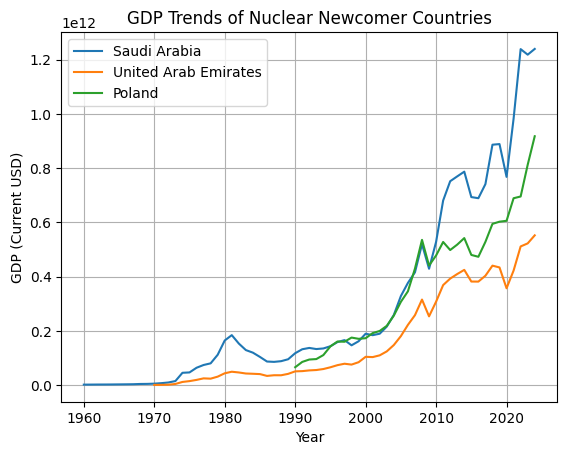

In [74]:
import matplotlib.pyplot as plt

for country in gdp_long["Country Name"].unique():
    subset = gdp_long[gdp_long["Country Name"] == country]
    plt.plot(subset["Year"], subset["GDP"], label=country)

plt.title("GDP Trends of Nuclear Newcomer Countries")
plt.xlabel("Year")
plt.ylabel("GDP (Current USD)")
plt.legend()
plt.grid(True)
plt.show()

In [75]:
gdp_long["GDP_indexed"] = gdp_long.groupby("Country Name")["GDP"].transform(
    lambda x: (x / x.iloc[0]) * 100
)

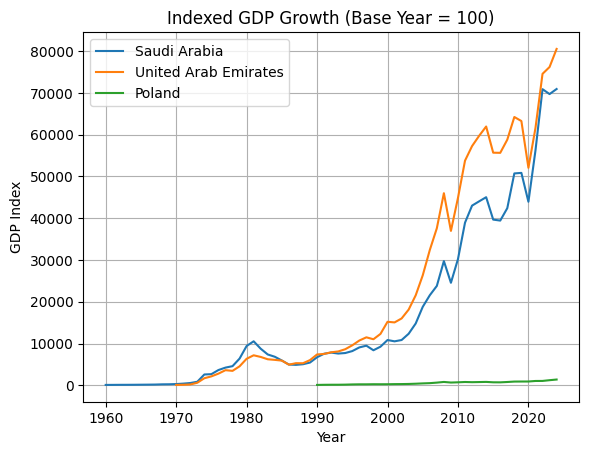

In [76]:
import matplotlib.pyplot as plt

for country in gdp_long["Country Name"].unique():
    subset = gdp_long[gdp_long["Country Name"] == country]
    plt.plot(subset["Year"], subset["GDP_indexed"], label=country)

plt.title("Indexed GDP Growth (Base Year = 100)")
plt.xlabel("Year")
plt.ylabel("GDP Index")
# plt.yscale("log")
plt.legend()
plt.grid(True)
plt.show()

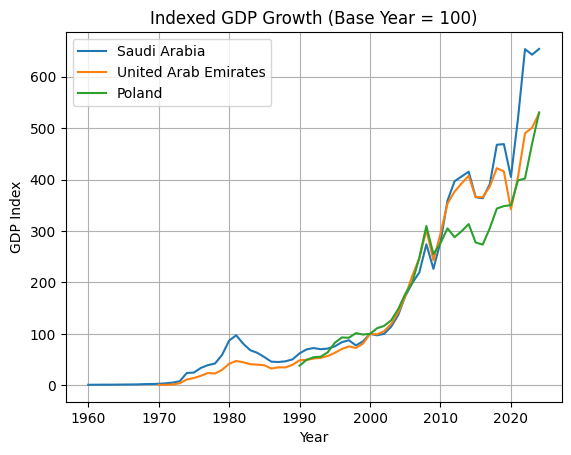

In [77]:
base_year = 2000

gdp_base = gdp_long[gdp_long["Year"] == base_year][["Country Name", "GDP"]]
gdp_base = gdp_base.rename(columns={"GDP": "GDP_base"})

gdp_long = gdp_long.merge(gdp_base, on="Country Name")

gdp_long["GDP_indexed"] = (gdp_long["GDP"] / gdp_long["GDP_base"]) * 100



import matplotlib.pyplot as plt

for country in gdp_long["Country Name"].unique():
    subset = gdp_long[gdp_long["Country Name"] == country]
    plt.plot(subset["Year"], subset["GDP_indexed"], label=country)

plt.title("Indexed GDP Growth (Base Year = 100)")
plt.xlabel("Year")
plt.ylabel("GDP Index")
# plt.yscale("log")
plt.legend()
plt.grid(True)
plt.show()

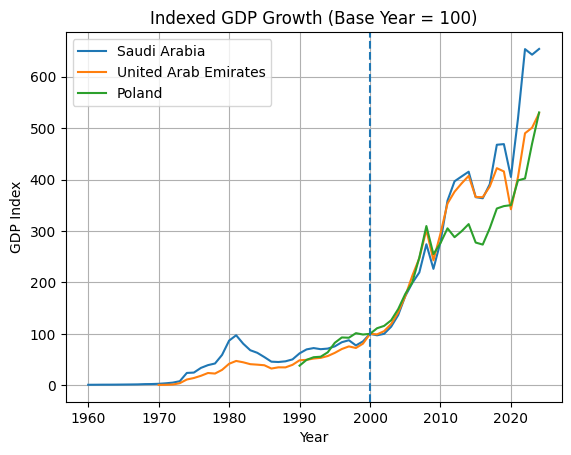

In [78]:
gdp_long["Country Name"].unique()


for country in gdp_long["Country Name"].unique():
    subset = gdp_long[gdp_long["Country Name"] == country]
    plt.plot(subset["Year"], subset["GDP_indexed"], label=country)

plt.title("Indexed GDP Growth (Base Year = 100)")
plt.xlabel("Year")
plt.ylabel("GDP Index")
# plt.yscale("log")
plt.legend()
plt.axvline(x=2000, linestyle='--')
plt.grid(True)
plt.show()


## Methodology

The dataset was cleaned and transformed using the following steps:

1. Imported World Bank GDP data and removed metadata rows.
2. Filtered for selected countries relevant to nuclear energy adoption.
3. Reshaped the dataset from wide to long format.
4. Converted year and GDP values into appropriate numeric formats.
5. Indexed GDP values using a base year of 2000 to enable cross-country comparison.
6. Visualized GDP growth trends using line plots.

This approach allows for consistent comparison of economic trajectories across countries with different baseline GDP levels.

### GDP Growth Trends (Indexed, Base Year = 2000)

Indexed GDP trends reveal distinct economic trajectories across nuclear newcomer countries.

- Saudi Arabia exhibits the strongest late-stage growth, though with notable volatility, reflecting its resource-driven economic structure.
- The United Arab Emirates demonstrates consistent and sustained growth, suggesting a diversified economy capable of supporting long-term infrastructure investment.
- Poland shows a delayed but steady upward trajectory, reflecting post-transition economic expansion and increasing industrial capacity.

Notably, all three countries experience accelerated growth after 2000, indicating broader structural shifts in global economic and energy demand conditions. These trends provide important context for understanding the financial and institutional capacity required for nuclear energy development.

## Interpretation 


## Limitations

This analysis focuses solely on GDP as a proxy for economic capacity and does not account for:

- Differences in energy policy frameworks across countries
- Variations in population size and per capita income
- External economic shocks (e.g., oil price volatility)
- Institutional and regulatory factors influencing nuclear adoption

Further analysis will incorporate energy production and nuclear-specific data to provide a more comprehensive assessment.